# Different Cartesian undersampling selecting the 26 central slices and the other with a Poisson Distribution

Checking the influence of the Cartesian Sampling Operator

### Import

In [16]:
# Import
import torch
import matplotlib.pyplot as plt
import mrpro

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from mrpro.operators import CartesianSamplingOp, FourierOp
from mrpro.data  import KData, IData
from mrpro.data.traj_calculators import KTrajectoryPulseq
from mrpro.data.SpatialDimension import SpatialDimension

# Local path
# US 93
h5_path1 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00095_FID06179_cartesian_2d_final_poiss_0_3_us_93_20240704_162827.h5'
seq_path1 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.3_us_93_20240704_162827.seq'

# US 256
h5_path2 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00097_FID06181_cartesian_2d_final_poiss_0_us_256_20240704_162847.h5'
seq_path2 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0_us_256_20240704_162847.seq'

# US 26
h5_path3 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00093_FID06177_cartesian_2d_final_poiss_0_01_us_26_20240704_162837.h5'
seq_path3 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.01_us_26_20240704_162837.seq'

# US 46
h5_path4 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00094_FID06178_cartesian_2d_final_poiss_0_1_us_46_20240704_162906.h5'
seq_path4 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.1_us_46_20240704_162906.seq'

# US 141
h5_path5 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00096_FID06180_cartesian_2d_final_poiss_0_5_us_141_20240704_162804.h5'
seq_path5 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.5_us_141_20240704_162804.seq'

### Fully sampled

/data/bouill01/conda_envs/py311/lib/python3.11/site-packages/skimage/metrics/simple_metrics.py:167: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


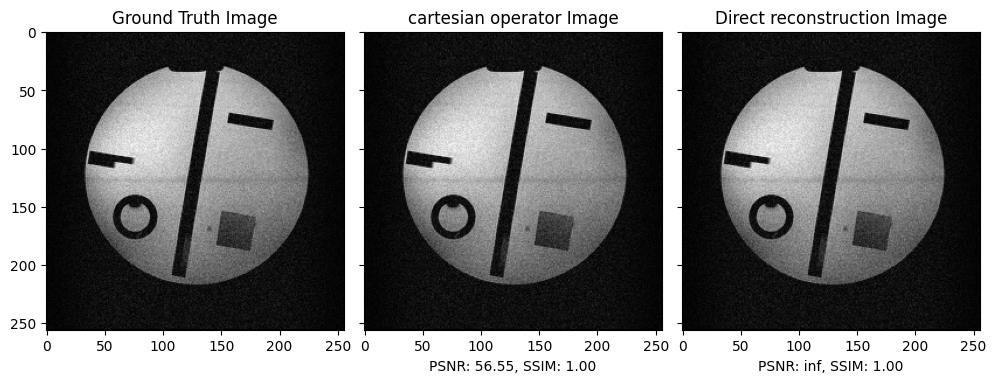

In [8]:
# Load and reconstruct ground truth data
kdatapuls_gt = KData.from_file(h5_path2, KTrajectoryPulseq(seq_path=seq_path2))
kdatapuls_gt.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

reconstructionpuls_gt = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls_gt)
img_gt = reconstructionpuls_gt(kdatapuls_gt)
first_img_gt = img_gt.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]

kdatapuls = KData.from_file(h5_path2, KTrajectoryPulseq(seq_path=seq_path2))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
img = reconstructionpuls(kdatapuls)
first_img = img.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]


# Create the Operator
encoding_matrix = kdatapuls.header.encoding_matrix
traj = kdatapuls.traj

cartesian_sampling_operator = CartesianSamplingOp(encoding_matrix, traj)
fourier_operator = FourierOp.from_kdata(kdatapuls)

sampling_fourier_operator = cartesian_sampling_operator @ fourier_operator
adjoint_operator = sampling_fourier_operator.H

# Calculate coil maps
img_coilwise = IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Perform Direct Reconstruction
forward_operator = sampling_fourier_operator @ csm_operator
adjoint_operator = forward_operator.H
img_us = IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
first_img_us = img_us.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]

# Compute SSIM and PSNR
ssim_value = ssim(first_img_gt, first_img_us, data_range=first_img_us.max() - first_img_us.min())
psnr_value = psnr(first_img_gt, first_img_us, data_range=first_img_us.max() - first_img_us.min())

ssim_value_dir = ssim(first_img_gt, first_img, data_range=first_img.max() - first_img.min())
psnr_value_dir = psnr(first_img_gt, first_img, data_range=first_img.max() - first_img.min())


fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharex=True, sharey=True)

ax[0].imshow(first_img_gt, cmap=plt.cm.gray)
ax[0].set_title('Ground Truth Image')

ax[1].imshow(first_img_us, cmap=plt.cm.gray)
ax[1].set_xlabel(f'PSNR: {psnr_value:.2f}, SSIM: {ssim_value:.2f}')
ax[1].set_title('cartesian operator Image')

ax[2].imshow(first_img, cmap=plt.cm.gray)
ax[2].set_xlabel(f'PSNR: {psnr_value_dir:.2f}, SSIM: {ssim_value_dir:.2f}')
ax[2].set_title('Direct reconstruction Image')


plt.tight_layout()
plt.show()


### Us 26

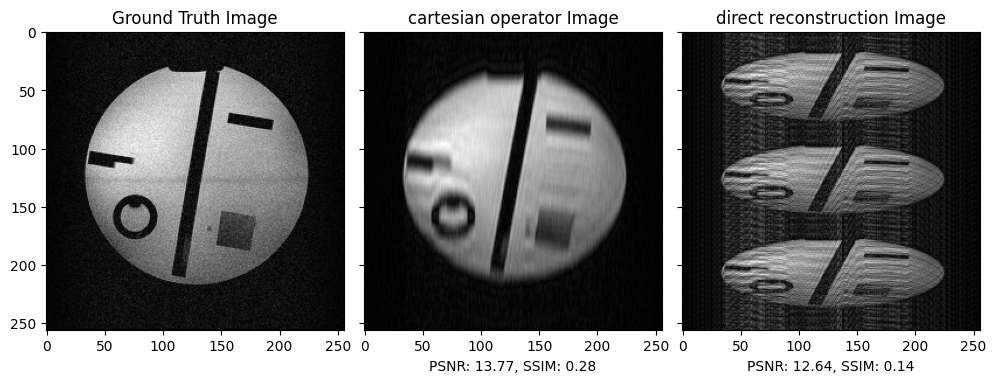

In [9]:
# Load and reconstruct ground truth data
kdatapuls_gt = KData.from_file(h5_path2, KTrajectoryPulseq(seq_path=seq_path2))
kdatapuls_gt.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

reconstructionpuls_gt = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls_gt)
img_gt = reconstructionpuls_gt(kdatapuls_gt)
first_img_gt = img_gt.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]


kdatapuls = KData.from_file(h5_path3, KTrajectoryPulseq(seq_path=seq_path3))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
img = reconstructionpuls(kdatapuls)
first_img = img.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]

# Load and reconstruct undersampled data with modifications
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
kdatapuls.header.encoding_matrix = SpatialDimension(z=1, y=256*3, x=256)

# Create the operator
encoding_matrix = kdatapuls.header.encoding_matrix
traj = kdatapuls.traj

cartesian_sampling_operator = CartesianSamplingOp(encoding_matrix, traj)
fourier_operator = FourierOp.from_kdata(kdatapuls)

sampling_fourier_operator = cartesian_sampling_operator @ fourier_operator
adjoint_operator = sampling_fourier_operator.H

# Calculate coil maps
img_coilwise = IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Perform Direct Reconstruction
forward_operator = sampling_fourier_operator @ csm_operator
adjoint_operator = forward_operator.H
img_us = IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
first_img_us = img_us.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]

# Compute SSIM and PSNR
ssim_value = ssim(first_img_gt, first_img_us, data_range=first_img_us.max() - first_img_us.min())
psnr_value = psnr(first_img_gt, first_img_us, data_range=first_img_us.max() - first_img_us.min())

ssim_value_dir = ssim(first_img_gt, first_img, data_range=first_img.max() - first_img.min())
psnr_value_dir = psnr(first_img_gt, first_img, data_range=first_img.max() - first_img.min())

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharex=True, sharey=True)

ax[0].imshow(first_img_gt, cmap=plt.cm.gray)
ax[0].set_title('Ground Truth Image')

ax[1].imshow(first_img_us, cmap=plt.cm.gray)
ax[1].set_xlabel(f'PSNR: {psnr_value:.2f}, SSIM: {ssim_value:.2f}')
ax[1].set_title('cartesian operator Image')

ax[2].imshow(first_img, cmap=plt.cm.gray)
ax[2].set_xlabel(f'PSNR: {psnr_value_dir:.2f}, SSIM: {ssim_value_dir:.2f}')
ax[2].set_title('direct reconstruction Image')


plt.tight_layout()
plt.show()


### US 46

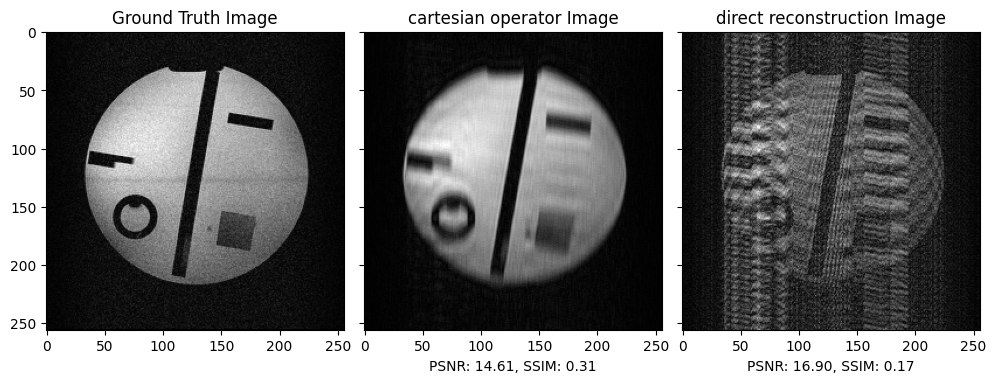

In [10]:
# Load and reconstruct ground truth data
kdatapuls_gt = KData.from_file(h5_path2, KTrajectoryPulseq(seq_path=seq_path2))
kdatapuls_gt.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

reconstructionpuls_gt = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls_gt)
img_gt = reconstructionpuls_gt(kdatapuls_gt)
first_img_gt = img_gt.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...] 


kdatapuls = KData.from_file(h5_path4, KTrajectoryPulseq(seq_path=seq_path4))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
img = reconstructionpuls(kdatapuls)
first_img = img.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]

# Load and reconstruct undersampled data with modifications
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

# Create the Operator
encoding_matrix = kdatapuls.header.encoding_matrix
traj = kdatapuls.traj

cartesian_sampling_operator = CartesianSamplingOp(encoding_matrix, traj)
fourier_operator = FourierOp.from_kdata(kdatapuls)

sampling_fourier_operator = cartesian_sampling_operator @ fourier_operator
adjoint_operator = sampling_fourier_operator.H

# Calculate coil maps
img_coilwise = IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Perform Direct Reconstruction
forward_operator = sampling_fourier_operator @ csm_operator
adjoint_operator = forward_operator.H
img_us = IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
first_img_us = img_us.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]

# Compute SSIM and PSNR
ssim_value = ssim(first_img_gt, first_img_us, data_range=first_img_us.max() - first_img_us.min())
psnr_value = psnr(first_img_gt, first_img_us, data_range=first_img_us.max() - first_img_us.min())

ssim_value_dir = ssim(first_img_gt, first_img, data_range=first_img.max() - first_img.min())
psnr_value_dir = psnr(first_img_gt, first_img, data_range=first_img.max() - first_img.min())


fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharex=True, sharey=True)

ax[0].imshow(first_img_gt, cmap=plt.cm.gray)
ax[0].set_title('Ground Truth Image')

ax[1].imshow(first_img_us, cmap=plt.cm.gray)
ax[1].set_xlabel(f'PSNR: {psnr_value:.2f}, SSIM: {ssim_value:.2f}')
ax[1].set_title('cartesian operator Image')

ax[2].imshow(first_img, cmap=plt.cm.gray)
ax[2].set_xlabel(f'PSNR: {psnr_value_dir:.2f}, SSIM: {ssim_value_dir:.2f}')
ax[2].set_title('direct reconstruction Image')


plt.tight_layout()
plt.show()


### US 93

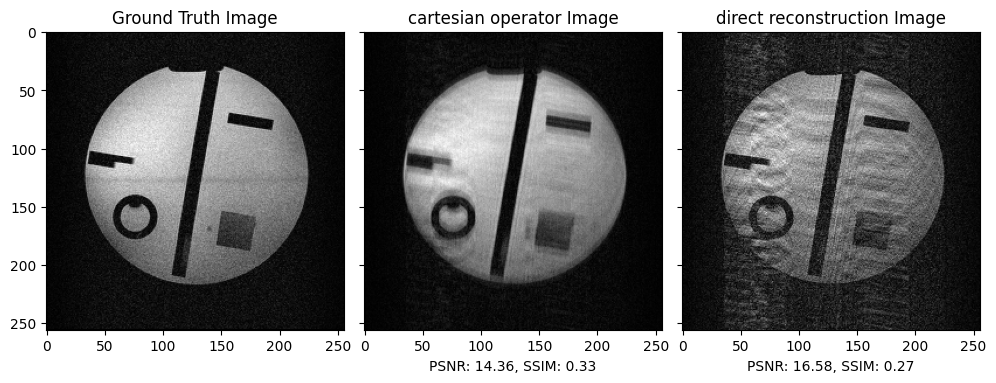

In [11]:
# Load and reconstruct ground truth data
kdatapuls_gt = KData.from_file(h5_path2, KTrajectoryPulseq(seq_path=seq_path2))
kdatapuls_gt.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

reconstructionpuls_gt = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls_gt)
img_gt = reconstructionpuls_gt(kdatapuls_gt) 
first_img_gt = img_gt.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...] 


kdatapuls = KData.from_file(h5_path1, KTrajectoryPulseq(seq_path=seq_path1))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
img = reconstructionpuls(kdatapuls)
first_img = img.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]

# Load and reconstruct undersampled data with modifications
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

# Create the Operator
encoding_matrix = kdatapuls.header.encoding_matrix
traj = kdatapuls.traj

cartesian_sampling_operator = CartesianSamplingOp(encoding_matrix, traj)
fourier_operator = FourierOp.from_kdata(kdatapuls)

sampling_fourier_operator = cartesian_sampling_operator @ fourier_operator
adjoint_operator = sampling_fourier_operator.H

# Calculate coil maps
img_coilwise = IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Perform Direct Reconstruction
forward_operator = sampling_fourier_operator @ csm_operator
adjoint_operator = forward_operator.H
img_us = IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
first_img_us = img_us.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]

# Compute SSIM and PSNR
ssim_value = ssim(first_img_gt, first_img_us, data_range=first_img_us.max() - first_img_us.min())
psnr_value = psnr(first_img_gt, first_img_us, data_range=first_img_us.max() - first_img_us.min())

ssim_value_dir = ssim(first_img_gt, first_img, data_range=first_img.max() - first_img.min())
psnr_value_dir = psnr(first_img_gt, first_img, data_range=first_img.max() - first_img.min())


fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharex=True, sharey=True)

ax[0].imshow(first_img_gt, cmap=plt.cm.gray)
ax[0].set_title('Ground Truth Image')

ax[1].imshow(first_img_us, cmap=plt.cm.gray)
ax[1].set_xlabel(f'PSNR: {psnr_value:.2f}, SSIM: {ssim_value:.2f}')
ax[1].set_title('cartesian operator Image')

ax[2].imshow(first_img, cmap=plt.cm.gray)
ax[2].set_xlabel(f'PSNR: {psnr_value_dir:.2f}, SSIM: {ssim_value_dir:.2f}')
ax[2].set_title('direct reconstruction Image')


plt.tight_layout()
plt.show()

### US 141

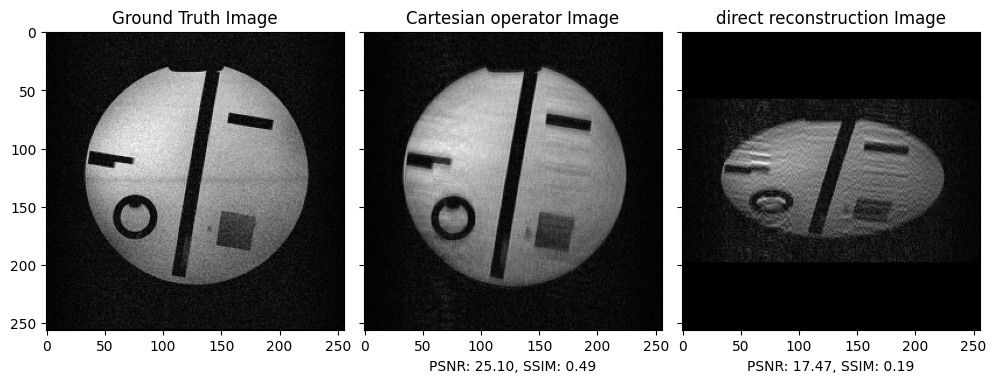

In [12]:
# Load and reconstruct ground truth data
kdatapuls_gt = KData.from_file(h5_path2, KTrajectoryPulseq(seq_path=seq_path2))
kdatapuls_gt.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

reconstructionpuls_gt = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls_gt)
img_gt = reconstructionpuls_gt(kdatapuls_gt)
first_img_gt = img_gt.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...] 


kdatapuls = KData.from_file(h5_path5, KTrajectoryPulseq(seq_path=seq_path5))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
img = reconstructionpuls(kdatapuls)
first_img = img.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]

# Load and reconstruct undersampled data with modifications
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

# Create the operator
encoding_matrix = kdatapuls.header.encoding_matrix
traj = kdatapuls.traj

cartesian_sampling_operator = CartesianSamplingOp(encoding_matrix, traj)
fourier_operator = FourierOp.from_kdata(kdatapuls)

sampling_fourier_operator = cartesian_sampling_operator @ fourier_operator
adjoint_operator = sampling_fourier_operator.H

# Calculate coil maps
img_coilwise = IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Perform Direct Reconstruction
forward_operator = sampling_fourier_operator @ csm_operator
adjoint_operator = forward_operator.H
img_us = IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
first_img_us = img_us.data.abs().to(dtype=torch.float64).numpy()[0,0,0,...]

# Compute SSIM and PSNR
ssim_value = ssim(first_img_gt, first_img_us, data_range=first_img_us.max() - first_img_us.min())
psnr_value = psnr(first_img_gt, first_img_us, data_range=first_img_us.max() - first_img_us.min())

ssim_value_dir = ssim(first_img_gt, first_img, data_range=first_img.max() - first_img.min())
psnr_value_dir = psnr(first_img_gt, first_img, data_range=first_img.max() - first_img.min())


fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharex=True, sharey=True)

ax[0].imshow(first_img_gt, cmap=plt.cm.gray)
ax[0].set_title('Ground Truth Image')

ax[1].imshow(first_img_us, cmap=plt.cm.gray)
ax[1].set_xlabel(f'PSNR: {psnr_value:.2f}, SSIM: {ssim_value:.2f}')
ax[1].set_title('Cartesian operator Image')

ax[2].imshow(first_img, cmap=plt.cm.gray)
ax[2].set_xlabel(f'PSNR: {psnr_value_dir:.2f}, SSIM: {ssim_value_dir:.2f}')
ax[2].set_title('direct reconstruction Image')


plt.tight_layout()
plt.show()
